<a href="https://colab.research.google.com/github/gonzH/ifes-redes-neurais-artificiais/blob/main/Trab03_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Prencha suas informações: { display-mode: "form" }

nome_completo = 'Hellesandro Gonzaga de Carvalho'  # @param {type: "string"}
matricula     = '20251MCPA0110'  # @param {type: "string"}

data = '2026-07-03'  # @param {type: "date"}
# @markdown ---

## Tarefa:

> Use as técnicas de forecasting apresentadas na aula em alguma base de dados diferente da apresentada na aula.

> Lembre-se de usar uma técnica ingênua (Naïve) como baseline.

> Explique a base que foi usada com poucas palavras. Justifique os parâmetros usados para gerar o dataset a partir do array.

## Sobre o dataset utilizado:

Base Usada: Shampoo Sales Dataset (https://github.com/jbrownlee/Datasets/blob/master/monthly-shampoo-sales.csv). Uma base pequena sobre a venda mensal de shampoo que tem tendência de crescimento.

Justificativa dos parâmetros:
- input_width = 6: 6 meses de histórico. Uma janela pequena para uma base pequena (36 meses), aumentar de mais ficaria com poucos exemplos para treinar.
 - label_width = 1: previsão do próximo mês
 - shift = 1: o alvo a ser previsto é o mês seguinte ao fim da janela de entrada.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# dataset: vendas mensais de shampoo ao longo de 3 anos (36 observações)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df = pd.read_csv(url)

# ajustando os dados para o formato de array
data = df['Sales'].values.astype('float32').reshape(-1, 1)

# normalizacao (estabilizar gradientes)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# divisão 80/20
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
val_data = data_scaled[train_size:]

print(f"Total de registros: {len(data_scaled)} | Treino: {len(train_data)} | Validação: {len(val_data)}")

Total de registros: 36 | Treino: 28 | Validação: 8


In [13]:
input_width = 6
label_width = 1
shift = 1

def make_dataset(data, input_width, label_width, shift):
    X, y = [], []
    for i in range(len(data) - input_width - shift + 1):
        X.append(data[i:(i + input_width)])
        y.append(data[(i + input_width + shift - 1):(i + input_width + shift - 1 + label_width)])
    return np.array(X), np.array(y)

X_train, y_train = make_dataset(train_data, input_width, label_width, shift)
X_val, y_val = make_dataset(val_data, input_width, label_width, shift)

print(f"Shape dos inputs (X_train): {X_train.shape} -> [Amostras, Passos no Tempo, Features]")

Shape dos inputs (X_train): (22, 6, 1) -> [Amostras, Passos no Tempo, Features]


In [15]:
modelos = {}

# Baseline

In [19]:
'''
   Naive Baseline: assume que a previsão para o próximo passo é igual ao último valor visto na janela de entrada.
'''
naive_preds = X_val[:, -1, :]
naive_mae = tf.keras.losses.MAE(y_val.squeeze(), naive_preds.squeeze()).numpy()

# Densely connected


In [20]:
modelos['Dense'] = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(input_width, 1)),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

# Conv1D

In [21]:
modelos['Conv1D'] = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(input_width, 1)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(units=1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# RNN

In [22]:
modelos['SimpleRNN'] = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units=16, activation='tanh', input_shape=(input_width, 1)),
    tf.keras.layers.Dense(units=1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# LSTM


In [23]:
modelos['LSTM'] = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=16, activation='tanh', input_shape=(input_width, 1)),
    tf.keras.layers.Dense(units=1)
])

# Stacking Recurrent Layers (LSTM empilhados)

In [24]:
modelos['Stacking_LSTM'] = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=16, activation='tanh', return_sequences=True, input_shape=(input_width, 1)),
    tf.keras.layers.LSTM(units=16, activation='tanh'),
    tf.keras.layers.Dense(units=1)
])

# Treino e avaliação do MAE

In [25]:
resultados_mae = {}

resultados_mae['Naive (Baseline)'] = naive_mae

for nome, modelo in modelos.items():
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='mae')
    modelo.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), verbose=0)

    # avaliação do erro no conjunto de validação
    mae = modelo.evaluate(X_val, y_val, verbose=0)
    resultados_mae[nome] = mae

# Comparação de resultados

In [28]:
for metodo, erro in sorted(resultados_mae.items(), key=lambda item: item[1]):
    print(f"{metodo:<25} | {erro:.4f}")

LSTM                      | 0.0530
Stacking_LSTM             | 0.0830
Conv1D                    | 0.1124
Dense                     | 0.1500
Naive (Baseline)          | 0.1525
SimpleRNN                 | 0.2568


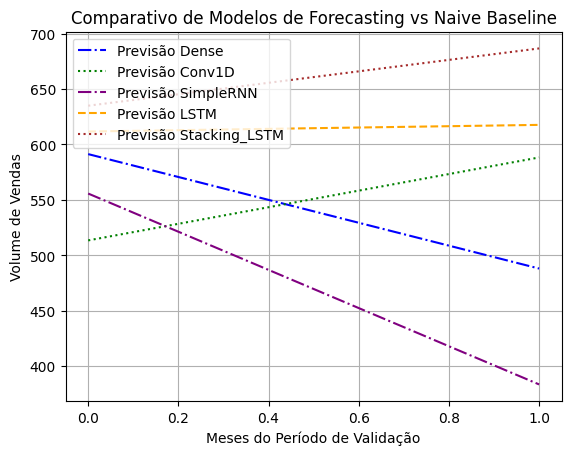

In [29]:
Estilos = ['-.', ':', '-.', '--', ':', '-']
Cores = ['blue', 'green', 'purple', 'orange', 'brown', 'cyan']

for i, (nome, modelo) in enumerate(modelos.items()):
    preds = modelo.predict(X_val, verbose=0)
    preds_reais = scaler.inverse_transform(preds)
    plt.plot(preds_reais, label=f"Previsão {nome}", linestyle=Estilos[i % len(Estilos)], color=Cores[i % len(Cores)])

plt.title("Comparativo de Modelos de Forecasting vs Naive Baseline")
plt.xlabel("Meses do Período de Validação")
plt.ylabel("Volume de Vendas")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()